# Value-recurrence prediction on CartPole-v1

**What this experiment asks.** As an ordinary DQN agent learns, does the value
signal along its trajectories become describable by a single linear recurrence
of low order? And if so, is that recurrence any use for *prediction* rather than
merely for description?

**The setup, in full.**

* The agent is a **plain baseline DQN**. There is no Hankel-rank regularisation
  term anywhere in the loss. Nothing pushes the agent towards low-rank values,
  so whatever structure appears is a property of ordinary Q-learning and not
  something the objective manufactured.
* Every `analysis.ep_freq` episodes the policy is **frozen** and rolled greedily
  (argmax, no exploration noise) from a fixed set of probe seeds. The values
  recorded are `V(state) = max over actions of Q(state, action)` at each step.
  Nothing about the agent is mutated by the probe.
* At each such checkpoint one **global** linear recurrence is fitted per order
  in the config's `autoregressive_value_probe.orders` — global meaning all the fitted trajectories are pooled, so
  the coefficients describe the policy rather than any single rollout.

**Two independent splits**, because "it fits" and "it predicts" are different claims:

| split | fitted on | scored on | the question it answers |
|---|---|---|---|
| held-out trajectories | some trajectories | *other* trajectories from the same frozen policy | does one recurrence describe this policy in general? |
| prefix / suffix | first half of each trajectory | second half of the same trajectory | given how a trajectory starts, does the recurrence say how it ends? |

**Two prediction regimes**, because a model can fit well and still be useless:

* **one step ahead** — every prediction is made from the *true* previous values,
  so errors never accumulate. The optimistic number.
* **free running** — seeded with `order` true values, then the recurrence runs on
  its own output. Errors compound. This is the honest test, and where an
  over-parameterised order shows itself.

Errors are reported as **normalised RMSE** (divided by the signal's own
root-mean-square), which is what makes CartPole and Acrobot comparable at all —
their raw value scales differ by orders of magnitude.

CartPole values are positive and grow towards the discounted horizon as the pole is balanced for longer, so the value signal along a good trajectory is a long, smooth, slowly saturating curve.

Everything below is also viewable interactively in the result viewer app:

```bash
python result_viewer_app/rank_viewer.py
```


## Setup

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt

REPOSITORY_ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))
sys.path.insert(0, str(REPOSITORY_ROOT / "experiments"))

from analysis.visualisations import autoregressive_value_plots as value_plots

plt.rcParams["figure.dpi"] = 110
CONFIG_PATH = "config_autoregressive_recurrence.yaml"


## Run the experiment

This trains the baseline DQN agent with the probe attached, writing every
artifact under `runs/<timestamp>/`. It takes a while; skip this cell and run the
next one instead to analyse a run that already exists.

In [2]:
from run_autoregressive_recurrence import run_experiment
run_directory, episode_rewards = run_experiment(CONFIG_PATH)
print(run_directory)


  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 21.0


  0%|          | 1/1500 [00:00<06:28,  3.86it/s]

  2%|▏         | 27/1500 [00:00<00:15, 94.58it/s]

**************** autoregressive value probe (80 trajectories, mean length 9) ****************
  order 2: held-out test normalised RMSE one-step 0.0072, free-running 0.0143
  order 4: held-out test normalised RMSE one-step 0.0063, free-running 0.0167
episode 10 avg_rewarg: 21.7
episode 20 avg_rewarg: 22.7
**************** autoregressive value probe (80 trajectories, mean length 9) ****************
  order 2: held-out test normalised RMSE one-step 0.0072, free-running 0.0143
  order 4: held-out test normalised RMSE one-step 0.0063, free-running 0.0167
episode 30 avg_rewarg: 21.9
episode 40 avg_rewarg: 18.5
episode 50 avg_rewarg: 22.6
**************** autoregressive value probe (80 trajectories, mean length 9) ****************
  order 2: held-out test normalised RMSE one-step 0.0072, free-running 0.0143
  order 4: held-out test normalised RMSE one-step 0.0063, free-running 0.0167


...

episode 1490 avg_rewarg: 11.2


100%|█████████▉| 1498/1500 [03:20<00:00, 33.18it/s]

100%|██████████| 1500/1500 [03:20<00:00,  7.49it/s]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260808-232139


/home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260808-232139


## Load the most recent run

In [3]:
# Picks by modification time among runs that actually contain probe output,
# so hand-named runs from other experiments in this directory are never chosen.
run_directory = value_plots.find_latest_run_with_probe("runs")
checkpoints = value_plots.available_rollout_episodes(run_directory)
# Read the orders from the run rather than hardcoding them: they come from
# autoregressive_value_probe.orders, so a run configured with [2, 4] has no
# order 3 or 8, and every cell below must follow whatever this run fitted.
ORDERS = value_plots.available_orders(run_directory)
FITTED_INTERCEPT = value_plots.fitted_with_intercept(run_directory)
print(f"run directory   : {run_directory}")
print(f"orders fitted   : {ORDERS}")
print(f"intercept fitted: {FITTED_INTERCEPT}")
print(f"checkpoints   : {len(checkpoints)}  "
      f"(episodes {checkpoints[0]} to {checkpoints[-1]})")


run directory   : runs/20260808-232139
orders fitted   : [2, 4]
intercept fitted: False
checkpoints   : 60  (episodes 0 to 1475)


## Learning curve

Context for everything that follows: a change in predictability is only
interesting if we know what the agent was doing at the time. The vertical lines
mark the probe checkpoints.

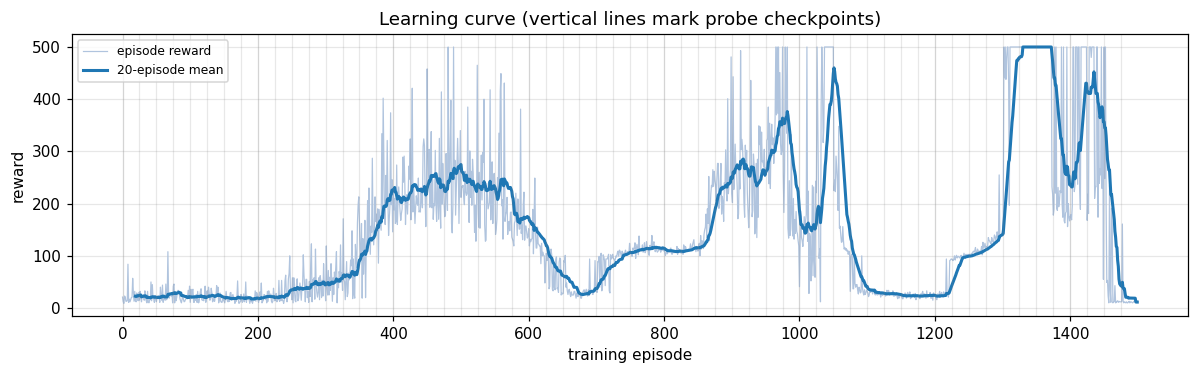

In [4]:
value_plots.plot_reward_with_checkpoints(run_directory);

## How predictable is the value signal, and does that change with training?

Four panels per split: one-step-ahead and free-running, each on the training and
the test portion. One line per recurrence order, log scale.

The panel that carries the claim is **free running / test** — the only one where
neither the trajectories nor the compounding of the recurrence's own errors were
seen during fitting.

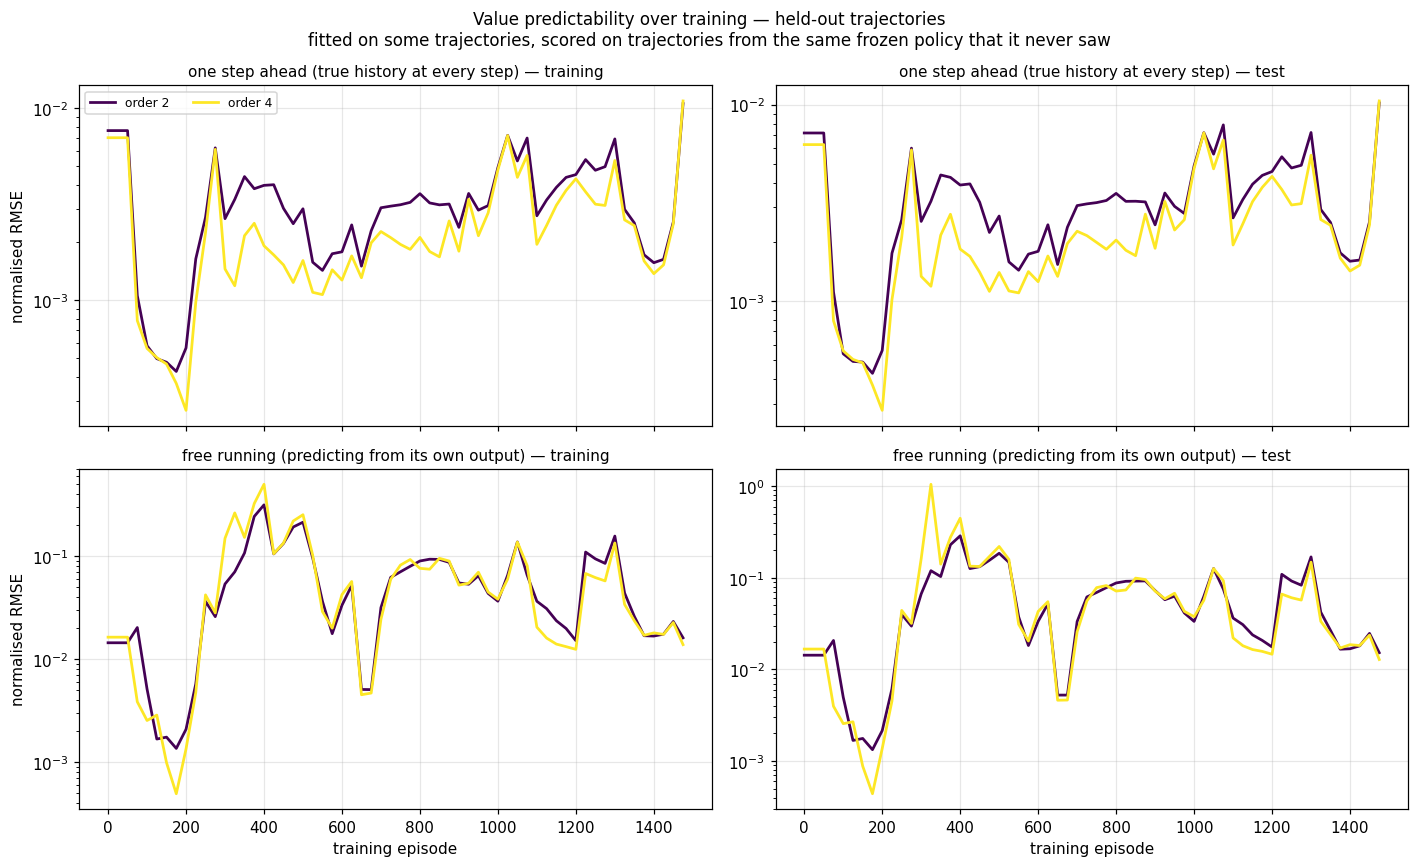

In [5]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.HELD_OUT_TRAJECTORY_SPLIT);

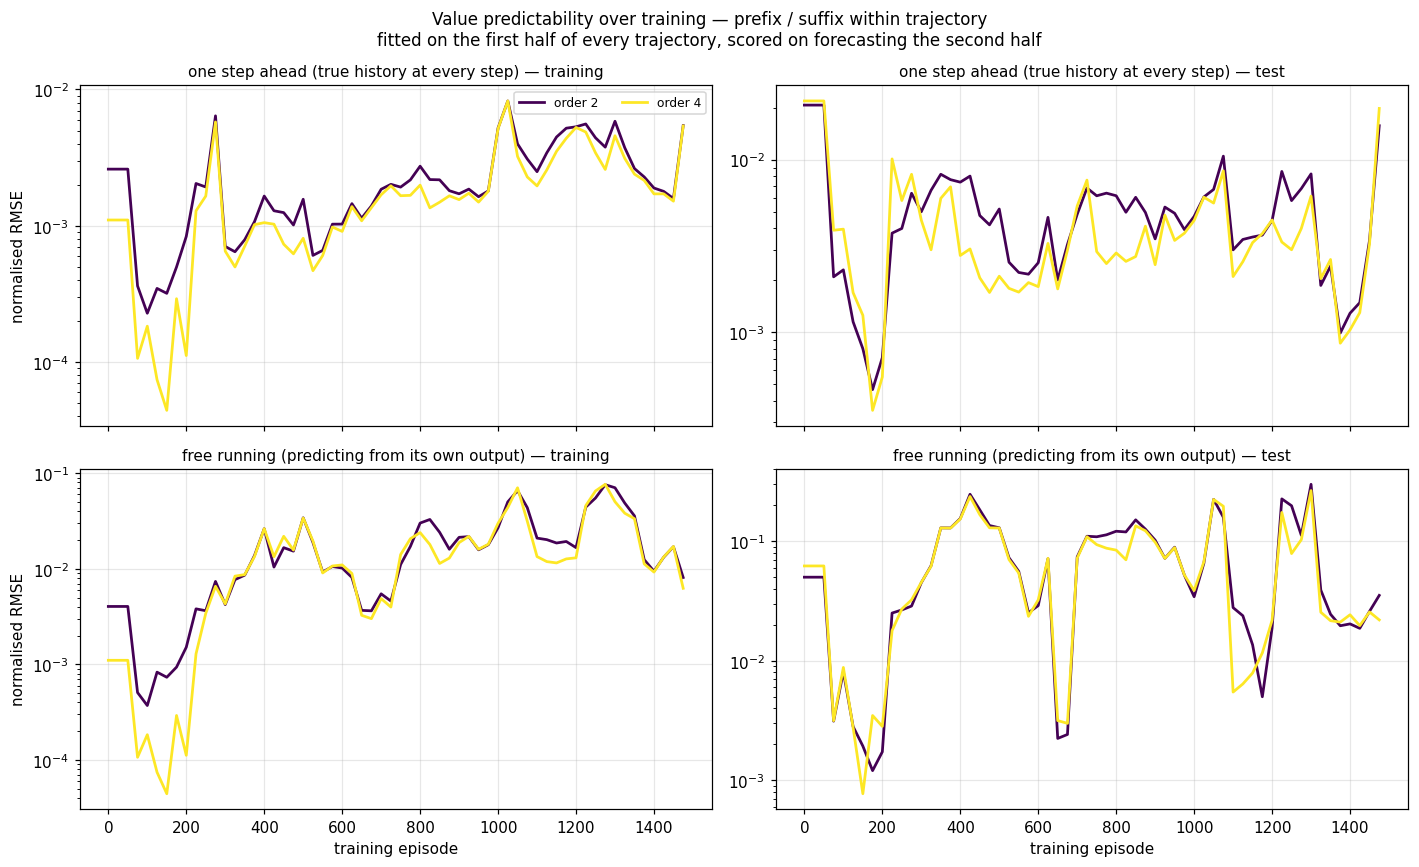

In [6]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.PREFIX_SUFFIX_SPLIT);

### Where it ended up

Held-out test errors at the final checkpoint. `diverged` flags a free-running
forecast that left the signal's scale entirely rather than producing a merely
large error.

In [7]:
value_plots.summarise_final_checkpoint(run_directory)

,order,one step ahead (nRMSE),free running (nRMSE),diverged,mean trajectory length
0,2,0.010213,0.015222,0,11.9125
1,4,0.010445,0.012834,0,11.9125


## How far ahead can the recurrence see?

The two regimes above are the extremes of one question. The **rolling-horizon**
sweep asks it properly: at horizon τ the recurrence predicts τ steps from the
true history, is then re-anchored on the values that actually occurred, and
predicts the next τ. That is how such a model would really be used — forecast a
little way, observe, forecast again.

The endpoints recover the other two regimes exactly:

* **τ = 1** is identical to one-step-ahead
* **τ longer than the trajectory** is identical to free running

so a single curve replaces both numbers and shows what neither could: the
horizon at which the recurrence stops being useful.

Reading the curve: one that **rises then flattens** has *saturated* — the
recurrence has decayed to predicting the signal's mean, so the error plateaus at
roughly the signal's own scale rather than growing without bound. One that
**keeps climbing steeply** is an unstable fit.

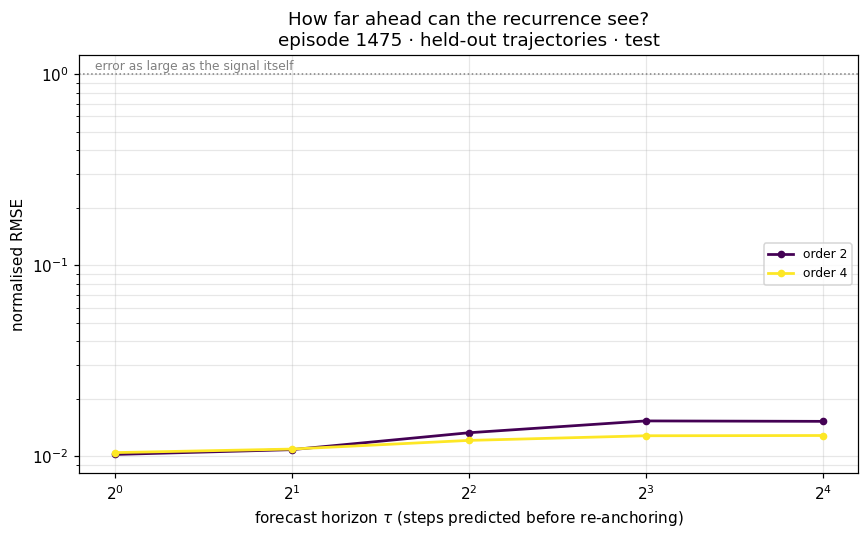

In [8]:
value_plots.plot_error_versus_forecast_horizon(run_directory);

The same numbers as a table — rows are recurrence orders, columns are horizons.

In [9]:
value_plots.summarise_horizon_sweep(run_directory).round(4)

,tau=1,tau=2,tau=4,tau=8,tau=16
order,,,,,
2,0.0102,0.0108,0.0133,0.0153,0.0152
4,0.0104,0.0109,0.0121,0.0128,0.0128


### Does the signal become predictable *further ahead* as the agent learns?

One line per horizon, across training. If the agent's value signal is genuinely
becoming more structured, the long-horizon lines should fall too — not just the
τ = 1 line.

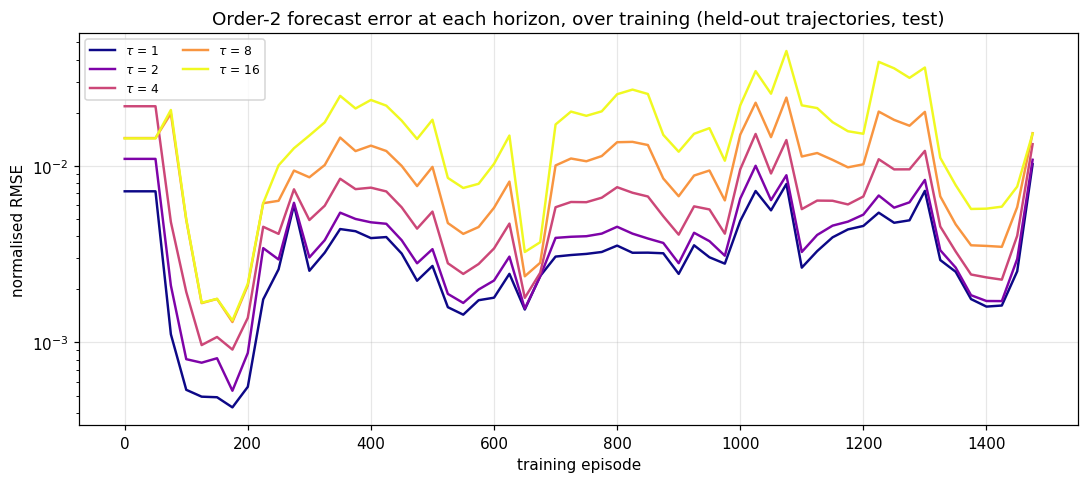

In [10]:
value_plots.plot_horizon_error_over_training(run_directory, order=ORDERS[0]);

## How do the coefficients themselves evolve?

One figure per recurrence order, one line per lag. Lag 1 is the weight on the
immediately preceding value.

The dashed line is the **sum of the lag weights**, and it is worth watching
separately from the individual coefficients: a sum near 1 is the persistence
(unit-root) regime, where the recurrence is mostly saying "the value stays where
it is". The individual weights can wander a great deal while that sum stays
pinned — which is a much more stable statement about the value signal than any
single coefficient is.

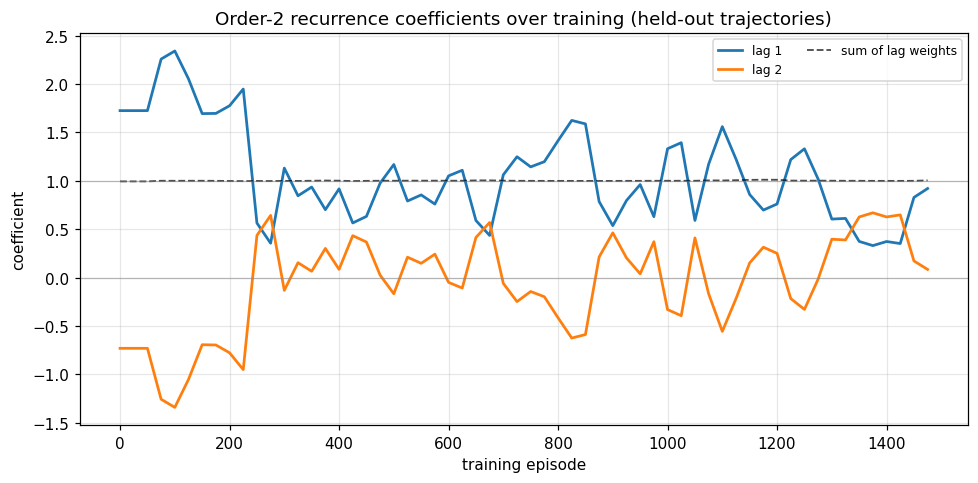

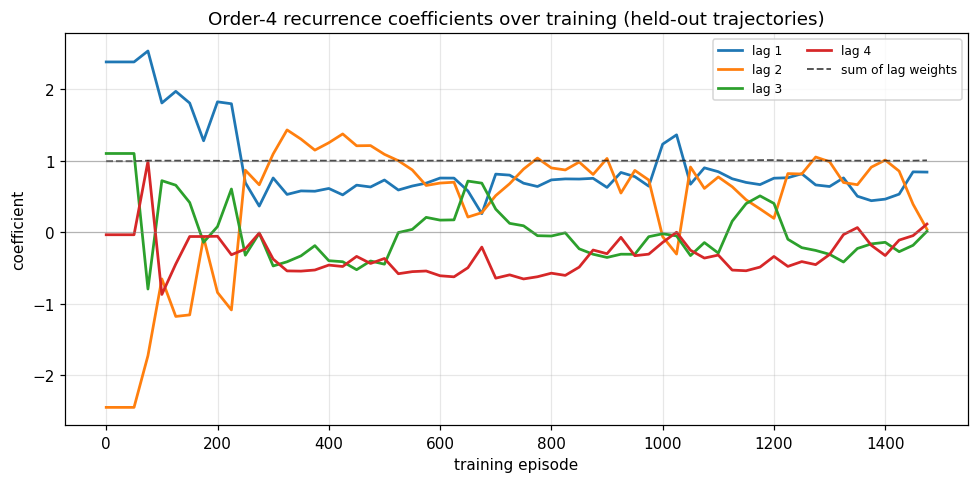

In [11]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(
        run_directory, order, include_intercept=FITTED_INTERCEPT);

### The same coefficients, from the prefix/suffix fit

A consistency check: coefficients fitted on first halves only should tell the
same story as coefficients fitted on whole trajectories, if the recurrence is a
property of the policy rather than an artefact of which segment was fitted.

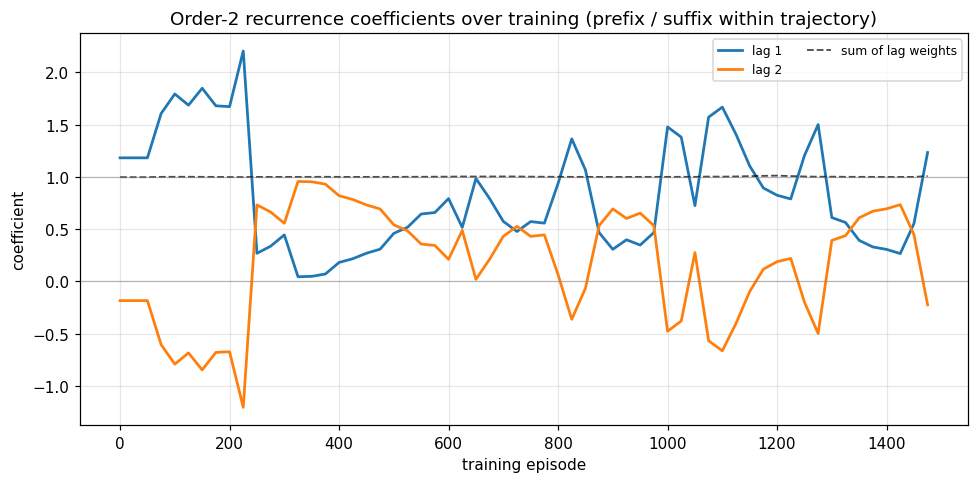

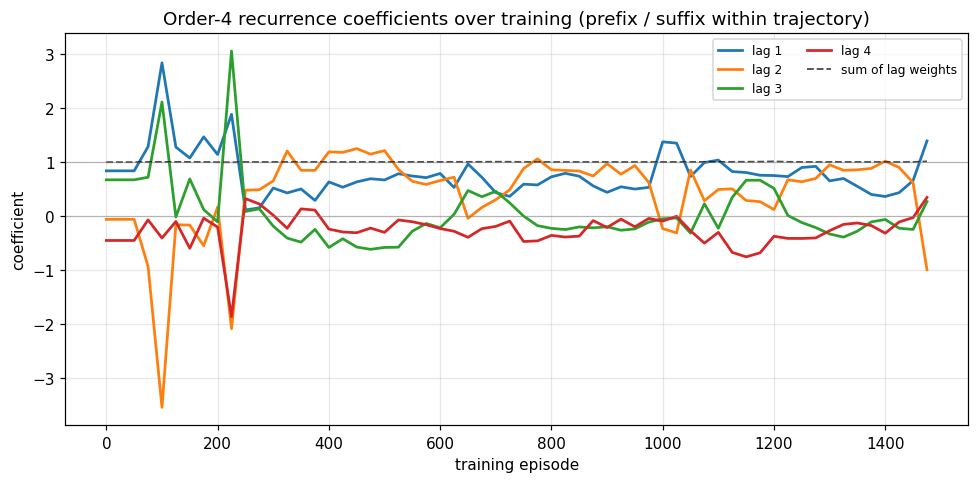

In [12]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(
        run_directory, order, split=value_plots.PREFIX_SUFFIX_SPLIT,
        include_intercept=FITTED_INTERCEPT);

## Example value rollouts: actual vs predicted

Single trajectories, with the true value in black, the one-step-ahead prediction
in blue and the free-running forecast dashed in red. Top row is the **training**
set, bottom row the **test** set, so the same order can be compared across the
two directly.

The gap between the blue and red lines is exactly how fast the recurrence loses
the signal once it stops being told the truth.

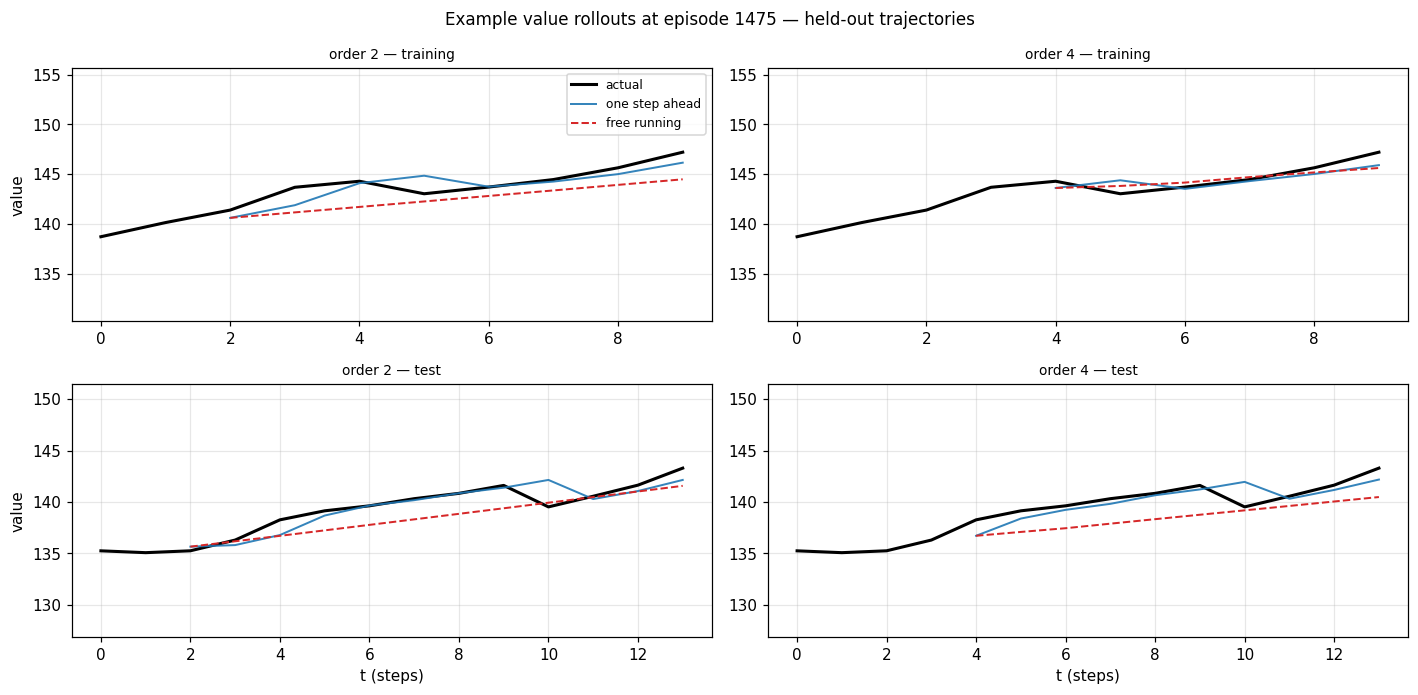

In [13]:
value_plots.plot_example_rollouts(run_directory);

### Earlier in training

The same plot at an early checkpoint, for comparison with the final one above.

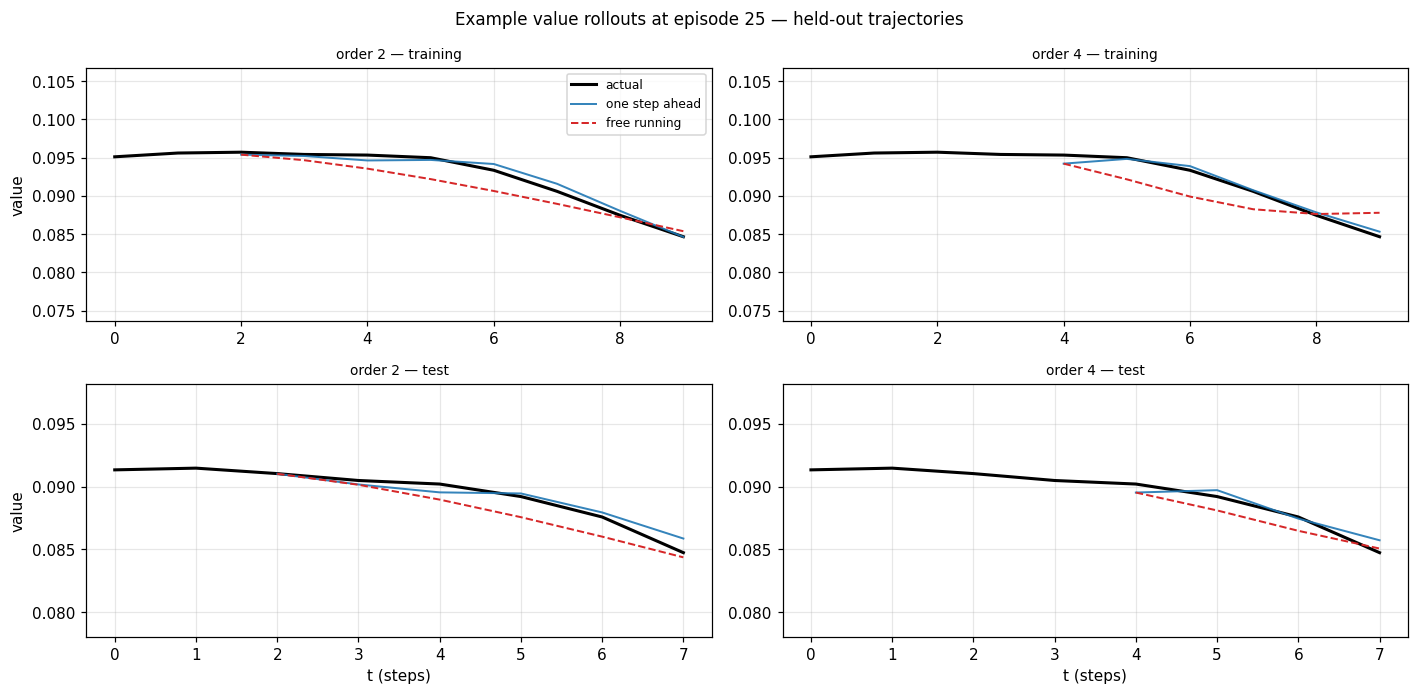

In [14]:
value_plots.plot_example_rollouts(run_directory, episode=checkpoints[1]);

### Forecasting the unseen second half

The prefix/suffix split, where the recurrence saw only the first half of these
very trajectories and has to forecast the rest.

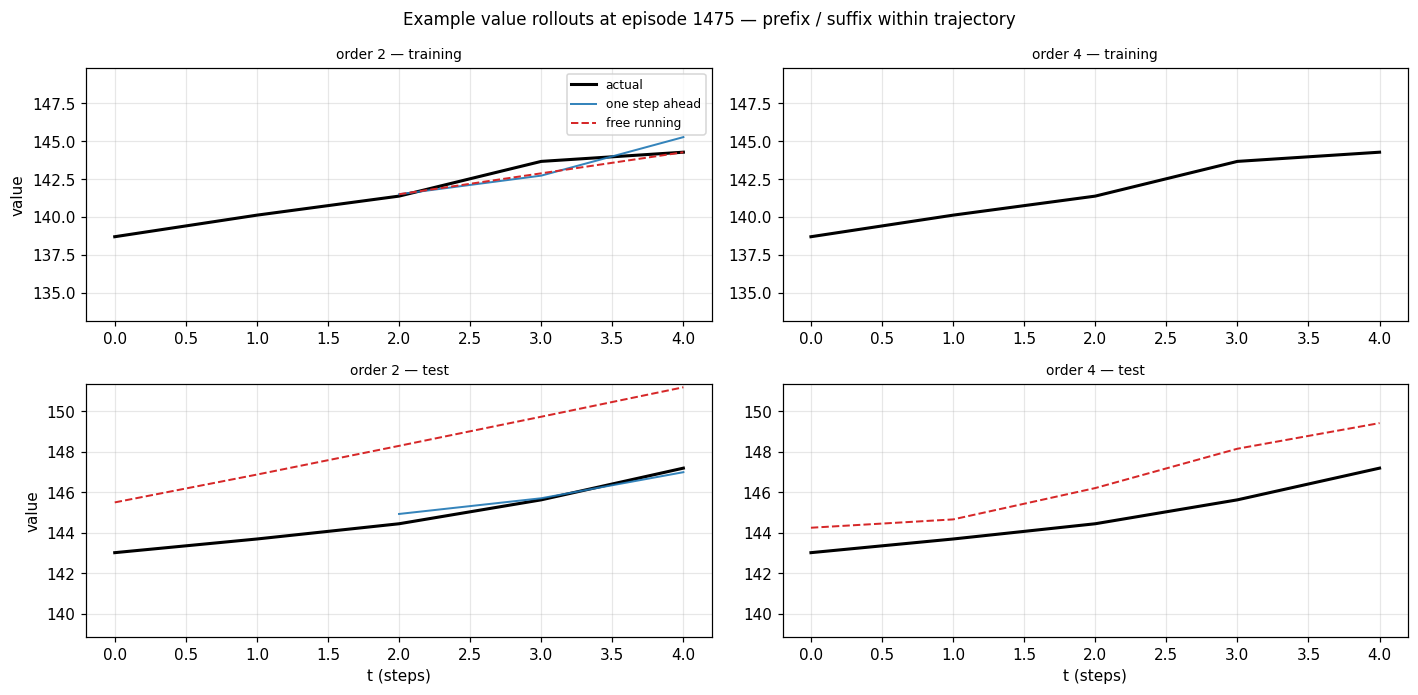

In [15]:
value_plots.plot_example_rollouts(
    run_directory, split=value_plots.PREFIX_SUFFIX_SPLIT);

## Raw artifacts

Everything plotted above is on disk and can be re-analysed without retraining:

| file | contents |
|---|---|
| `autoregressive_value_metrics.csv` | one row per (episode, order, split, subset) with both error measures |
| `autoregressive_value_coefficients.csv` | one row per (episode, order, split, lag); lag 0 is the intercept |
| `autoregressive_rollouts/epNNNNNN.npz` | actual / one-step-ahead / free-running arrays for the example trajectories |
| `rewards.csv`, `checkpoints/` | the ordinary training artifacts |


In [16]:
import pandas as pd
pd.read_csv(run_directory / "autoregressive_value_metrics.csv").tail(8)

,episode,order,split,subset,rmse_one_step_ahead,normalised_rmse_one_step_ahead,rmse_free_running,normalised_rmse_free_running,free_running_diverged,n_sequences_scored,n_trajectories_collected,mean_trajectory_length
472,1475,2,held_out_trajectory_split,training,1.500198,0.010567,2.289334,0.016125,0,48,80,11.9125
473,1475,2,held_out_trajectory_split,test,1.445210,0.010213,2.154014,0.015222,0,32,80,11.9125
474,1475,2,prefix_suffix_split,training,0.761637,0.005434,1.136082,0.008106,0,80,80,11.9125
475,1475,2,prefix_suffix_split,test,2.250712,0.015752,5.027553,0.035218,0,80,80,11.9125
476,1475,4,held_out_trajectory_split,training,1.555689,0.010909,1.973928,0.013842,0,48,80,11.9125
477,1475,4,held_out_trajectory_split,test,1.484372,0.010445,1.823969,0.012834,0,32,80,11.9125
478,1475,4,prefix_suffix_split,training,0.762222,0.005400,0.882456,0.006252,0,79,80,11.9125
479,1475,4,prefix_suffix_split,test,2.827081,0.019834,3.135025,0.021968,0,79,80,11.9125
